In [26]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import files

# --- Preprocessing ---
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# --- Models ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# --- Evaluation ---
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("All libraries imported successfully.")

# ==============================================================================
# 2. UPLOAD & LOAD DATA
# ==============================================================================

print("\nPlease upload your 'train_ready.csv' file:")
uploaded_train = files.upload()

print("\nPlease upload your 'test_ready.csv' file:")
uploaded_test = files.upload()

# Get the file names (assuming they are named as expected)
train_file_name = "train_ready.csv"
test_file_name = "test_ready.csv"

if train_file_name not in uploaded_train or test_file_name not in uploaded_test:
    print("\nError: Make sure you upload both 'train_ready.csv' and 'test_ready.csv'.")
else:
    print(f"\nSuccessfully uploaded both files!")

    # Load the files into pandas DataFrames
    df_train = pd.read_csv(io.BytesIO(uploaded_train[train_file_name]))
    df_test = pd.read_csv(io.BytesIO(uploaded_test[test_file_name]))

    print(f"\nTraining data shape: {df_train.shape}")
    print(f"Test data shape: {df_test.shape}")

All libraries imported successfully.

Please upload your 'train_ready.csv' file:


Saving train_ready.csv to train_ready.csv

Please upload your 'test_ready.csv' file:


Saving test_ready.csv to test_ready.csv

Successfully uploaded both files!

Training data shape: (32000, 44)
Test data shape: (8000, 44)


In [27]:
# ==============================================================================
# 3. DEFINE FEATURES (X) AND TARGET (y)
# ==============================================================================

target = 'final_price'

# CRITICAL STEP: Define features to DROP.
# We drop IDs, dates, and "leaky" columns (ones that are too similar to the target).
# 'listing_price' and 'offer_price' would make the model trivially easy and useless.
# 'price_per_sqft' is calculated FROM 'final_price', so it must be dropped.
drop_features = [
    target, 'deal_id', 'customer_id', 'broker_id', 'property_id',
    'deal_date', 'close_date',
    'listing_price', 'offer_price', 'price_per_sqft', # Very important to drop!
    'status', 'price_band', # These are also targets, not features
    'amenities' # The raw text column (we'll use the one-hot flags if you made them)
]

# Automatically identify numeric and categorical features from remaining columns
all_cols = df_train.columns.tolist()
potential_features = [col for col in all_cols if col not in drop_features]

# Ensure we only use columns that are actually present
numeric_features = df_train[potential_features].select_dtypes(include=np.number).columns.tolist()
categorical_features = df_train[potential_features].select_dtypes(include='object').columns.tolist()

print(f"\n--- Model Setup ---")
print(f"Target (y): {target}")
print(f"Found {len(numeric_features)} numeric features (e.g., 'area_sqft', 'bedrooms').")
print(f"Found {len(categorical_features)} categorical features (e.g., 'city', 'property_type').")

# Separate data into X and y for train and test sets
X_train = df_train[numeric_features + categorical_features]
y_train = df_train[target]

X_test = df_test[numeric_features + categorical_features]
y_test = df_test[target]

print("\nX_train, y_train, X_test, y_test are ready.")


--- Model Setup ---
Target (y): final_price
Found 25 numeric features (e.g., 'area_sqft', 'bedrooms').
Found 6 categorical features (e.g., 'city', 'property_type').

X_train, y_train, X_test, y_test are ready.


In [28]:
# ==============================================================================
# 4. BUILD THE PREPROCESSING PIPELINE
# ==============================================================================

# This pipeline will automatically:
# 1. Fill missing numeric values with the median.
# 2. Scale all numeric values (like 'area_sqft').
# 3. Fill missing text values with "missing".
# 4. One-hot encode all text values (like 'city').

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep any columns not listed
)

print("\nPreprocessing pipeline created successfully.")
print("The 'preprocessor' object is now ready to be used in a model.")


Preprocessing pipeline created successfully.
The 'preprocessor' object is now ready to be used in a model.


In [29]:
# ==============================================================================
# 5. DEFINE, TRAIN, AND EVALUATE 5 MODELS
# ==============================================================================

# Define the 5 regression models you requested
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = [] # To store evaluation metrics
fitted_pipelines = {} # To store the trained models

print("\n--- Starting Model Training & Evaluation Loop ---")

for name, model in models.items():
    print(f"Training {name}...")

    # Create the full pipeline: 1. Preprocess -> 2. Model
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train the model
    pipe.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = pipe.predict(X_test)

    # Calculate evaluation metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

    # Store the fitted pipeline
    fitted_pipelines[name] = pipe

print("--- Model Training Complete ---")

# Create a DataFrame from the results and print it
results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)

print("\n--- Automated Model Evaluation ---")
print(results_df.to_markdown(index=False))


--- Starting Model Training & Evaluation Loop ---
Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training Random Forest...
Training Gradient Boosting...
--- Model Training Complete ---

--- Automated Model Evaluation ---
| Model             |      RMSE |        MAE |       R2 |
|:------------------|----------:|-----------:|---------:|
| Random Forest     | 0.014484  | 0.00587043 | 0.999785 |
| Gradient Boosting | 0.0311904 | 0.0230176  | 0.999005 |
| Ridge Regression  | 0.653218  | 0.515079   | 0.563558 |
| Linear Regression | 0.653219  | 0.515076   | 0.563557 |
| Lasso Regression  | 0.671538  | 0.538362   | 0.538733 |



Generating model comparison plots...


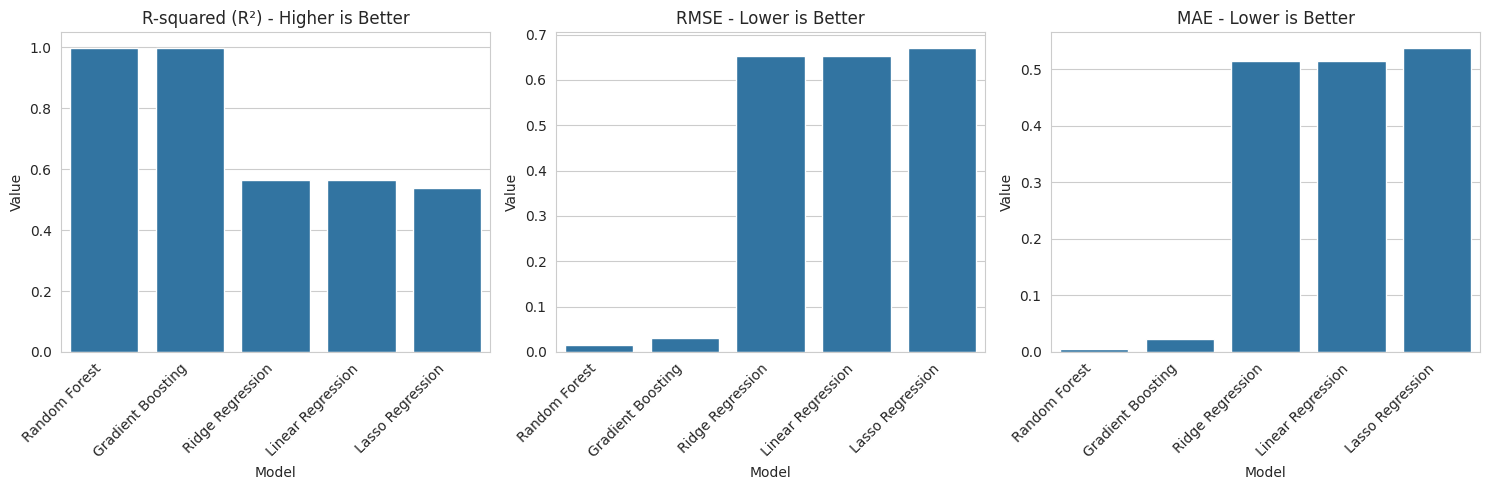

In [30]:
# ==============================================================================
# 6. MODEL COMPARISON VISUALIZATIONS
# ==============================================================================

print("\nGenerating model comparison plots...")

# Melt the DataFrame for easy plotting with seaborn
results_melted = results_df.melt('Model', var_name='Metric', value_name='Value')

# Plot RMSE, MAE, and R2
plt.figure(figsize=(15, 5))

# Plot R2 (Higher is better)
plt.subplot(1, 3, 1)
sns.barplot(data=results_melted[results_melted['Metric'] == 'R2'], x='Model', y='Value')
plt.title('R-squared (R²) - Higher is Better')
plt.xticks(rotation=45, ha='right')

# Plot RMSE (Lower is better)
plt.subplot(1, 3, 2)
sns.barplot(data=results_melted[results_melted['Metric'] == 'RMSE'], x='Model', y='Value')
plt.title('RMSE - Lower is Better')
plt.xticks(rotation=45, ha='right')

# Plot MAE (Lower is better)
plt.subplot(1, 3, 3)
sns.barplot(data=results_melted[results_melted['Metric'] == 'MAE'], x='Model', y='Value')
plt.title('MAE - Lower is Better')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


--- Deep-Dive Analysis for Best Model: Random Forest ---
Generating Prediction vs. Actual Plot...


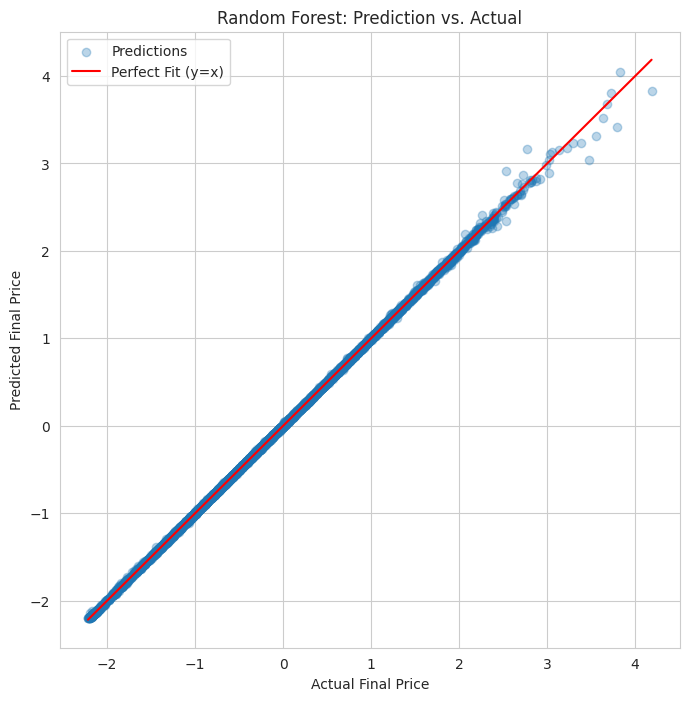

Generating Residual Plots...


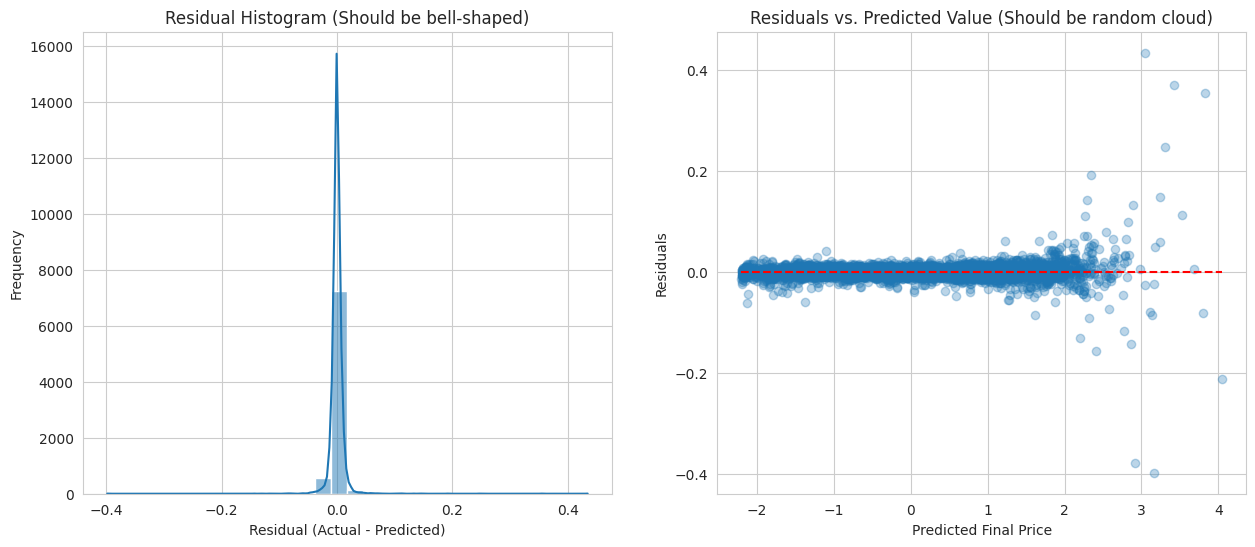

In [31]:
# ==============================================================================
# 7. BEST MODEL SELECTION & DEEP-DIVE ANALYSIS
# ==============================================================================

# Auto-select the best model based on the highest R-squared
best_model_name = results_df.iloc[0]['Model']
best_pipeline = fitted_pipelines[best_model_name]

print(f"\n--- Deep-Dive Analysis for Best Model: {best_model_name} ---")

# Re-calculate predictions for the best model
y_pred_best = best_pipeline.predict(X_test)

# --- 7a. Prediction vs. Actual Plot ---
print("Generating Prediction vs. Actual Plot...")
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.3, label='Predictions')
# Plot the perfect 'y=x' line
line = np.linspace(min(y_test.min(), y_pred_best.min()),
                   max(y_test.max(), y_pred_best.max()), 100)
plt.plot(line, line, 'r-', label='Perfect Fit (y=x)')
plt.title(f'{best_model_name}: Prediction vs. Actual')
plt.xlabel('Actual Final Price')
plt.ylabel('Predicted Final Price')
plt.legend()
plt.grid(True)
plt.show()

# --- 7b. Residual Analysis ---
print("Generating Residual Plots...")
residuals = y_test - y_pred_best

plt.figure(figsize=(15, 6))

# Plot 1: Histogram of Residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, bins=30)
plt.title('Residual Histogram (Should be bell-shaped)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')

# Plot 2: Scatter Plot of Residuals vs. Predicted Value
plt.subplot(1, 2, 2)
plt.scatter(y_pred_best, residuals, alpha=0.3)
plt.hlines(0, xmin=y_pred_best.min(), xmax=y_pred_best.max(), colors='red', linestyles='--')
plt.title('Residuals vs. Predicted Value (Should be random cloud)')
plt.xlabel('Predicted Final Price')
plt.ylabel('Residuals')
plt.show()

Generating Feature Importance Plot...


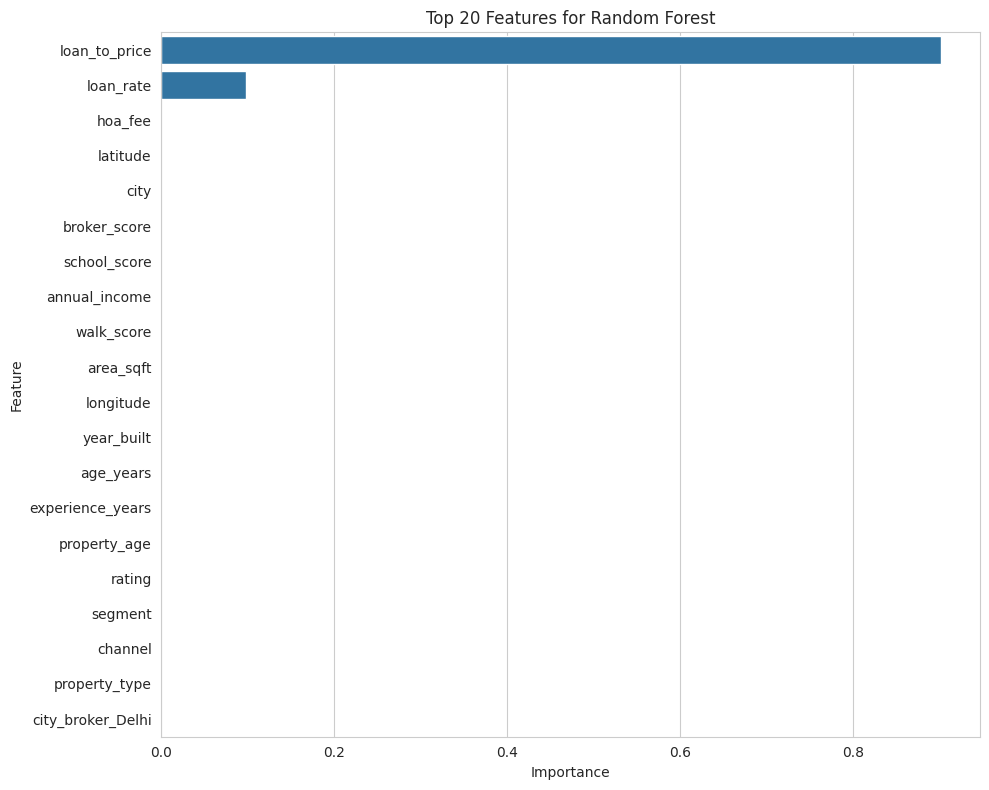


--- Saving Best Model (Random Forest) ---
Model saved as 'best_real_estate_model.joblib'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


To load this model later, use:
import joblib
loaded_model = joblib.load('best_real_estate_model.joblib')
new_predictions = loaded_model.predict(new_data)

--- ALL TASKS COMPLETE ---


In [32]:
# ==============================================================================
# 8. FEATURE IMPORTANCE & SAVING THE MODEL
# ==============================================================================

print("Generating Feature Importance Plot...")

# Get the model object from the pipeline
model_in_pipeline = best_pipeline.named_steps['model']

# Get the preprocessor object
preprocessor_in_pipeline = best_pipeline.named_steps['preprocessor']

# Get encoded feature names
try:
    # Get feature names from the 'onehot' step in the 'cat' transformer
    encoded_cat_features = preprocessor_in_pipeline.named_transformers_['cat'] \
                            .named_steps['onehot'] \
                            .get_feature_names_out(categorical_features)

    # Combine with original numeric features
    all_feature_names = np.concatenate([numeric_features, encoded_cat_features])

    # Get feature importances (works for RF, GB) or coefficients (for Linear/Ridge/Lasso)
    if hasattr(model_in_pipeline, 'feature_importances_'):
        importances = model_in_pipeline.feature_importances_
    elif hasattr(model_in_pipeline, 'coef_'):
        importances = np.abs(model_in_pipeline.coef_)
    else:
        print(f"Cannot get feature importances for {best_model_name}")
        importances = None

    if importances is not None:
        # Create a DataFrame
        feature_importance_df = pd.DataFrame({
            'Feature': all_feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)

        # Plot the top 20 features
        plt.figure(figsize=(10, 8))
        sns.barplot(
            data=feature_importance_df.head(20),
            y='Feature',
            x='Importance'
        )
        plt.title(f'Top 20 Features for {best_model_name}')
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"\nError getting feature names, skipping plot: {e}")
    print("This can happen if the 'cat' transformer was not used (e.g., no categorical features).")

# ==============================================================================
# 9. SAVE THE BEST MODEL
# ==============================================================================

model_filename = 'best_real_estate_model.joblib'

print(f"\n--- Saving Best Model ({best_model_name}) ---")

# Save the entire pipeline (preprocessor + model) to a file
joblib.dump(best_pipeline, model_filename)

print(f"Model saved as '{model_filename}'.")

# Trigger download in Colab
files.download(model_filename)

print(f"\nTo load this model later, use:")
print(f"import joblib")
print(f"loaded_model = joblib.load('{model_filename}')")
print(f"new_predictions = loaded_model.predict(new_data)")

print("\n--- ALL TASKS COMPLETE ---")